# Data Science in Psychology and Neuroscience

## Class info:
* Week #12
* Day: April 7, 2026
* Time: 9:30—10:45 AM
* Location: Logan Hall 125
* <a href="https://forms.microsoft.com/r/26vAcJWrwH">Click here to submit your attendance for Week 12, Question 21!</a>
  
## Instructor info:
* Dr. Jeremy Hogeveen
* jhogeveen@unm.edu
* Logan Hall 281 (Office Hours By Appointment)
  
## Syllabus:
* <a href="https://www.dropbox.com/scl/fi/6fs6fi4kvkwtxn7j7x8ua/PSY450650_DSPN_Spring2026_Syllabus.pdf?rlkey=148e5t4ah8q2n1daclt7mp0h6&dl=0">Download here</a>

## Today's topic:
* Modeling our ketamine trial data, continued
1. Linear Mixed Models (LMMs).
2. Testing the assumptions of the GLM.
3. My suggestions for GLM violations: Use robust estimators.

 

# Section 1. Linear Mixed Models

## 1.1 Refresher: We started by running a `3 (time: pre, posttest, followup)` x `3 (drug: ketamine, amphetamine, placebo)` Mixed ANOVA (omnibus test)
*  Are there differences in the long-term antidepressant effects of ketamine versus amphetamine versus placebo?
*  This represents the omnibus test for this design.
    *  AKA, what we'd actually run first if this was our study. Why?
        * Multiple comparisons issues:
            * At this point, we'd run i) a `paired t-test`, ii) an `independent t-test`, iii) a `one-way ANOVA`, and iv) a `rm-ANOVA`.
            * Family-Wise Error Rate (FWER): $FWER =  1 - (1 - \alpha)^n$.
                * $FWER = 1 - (1 - 0.95)^4$
                * $FWER = 0.1855$
                * False positive rate has ≈quadrupled.
        * Maximizes statistical power:
            * Using all subjects + data points to estimate error variance.
            * Higher error degrees of freedom in the ANOVA denominator, lower critical threshold for significance.
        * Capturing the critical `interaction term` (drug * time)
            * Does the trajectory of change depend on the drug? Only the interaction term in the omnibus model does that.

In [1]:
# package loadings
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(library(rstatix))
suppressPackageStartupMessages(library(afex))
suppressPackageStartupMessages(library(emmeans))
suppressPackageStartupMessages(library(knitr))
suppressPackageStartupMessages(library(lme4))
suppressPackageStartupMessages(library(lmerTest))
suppressPackageStartupMessages(library(ggeffects))
suppressPackageStartupMessages(library(gridExtra))

In [2]:
# Load in our data
df <- read_csv('../data/synth_ketamine_data.csv')

# Reorder our factors accordingly
Time_desired_order <- c("Pre", "Post", "Followup")
df$Time <- factor(df$Time, levels = Time_desired_order)
Drug_desired_order <- c("Placebo", "Amphetamine", "Ketamine")
df$Drug <- factor(df$Drug, levels = Drug_desired_order)

head(df)

Rows: 180 Columns: 5
── Column specification ─────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Drug, Time
dbl (3): Subject, Change, HAMD

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Subject,Drug,Change,Time,HAMD
<dbl>,<fct>,<dbl>,<fct>,<dbl>
1,Ketamine,10.89830,Pre,28.112875
1,Ketamine,10.89830,Post,17.214579
1,Ketamine,10.89830,Followup,15.227329
2,Ketamine,12.55569,Pre,22.305905
2,Ketamine,12.55569,Post,9.750214
2,Ketamine,12.55569,Followup,7.809342


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


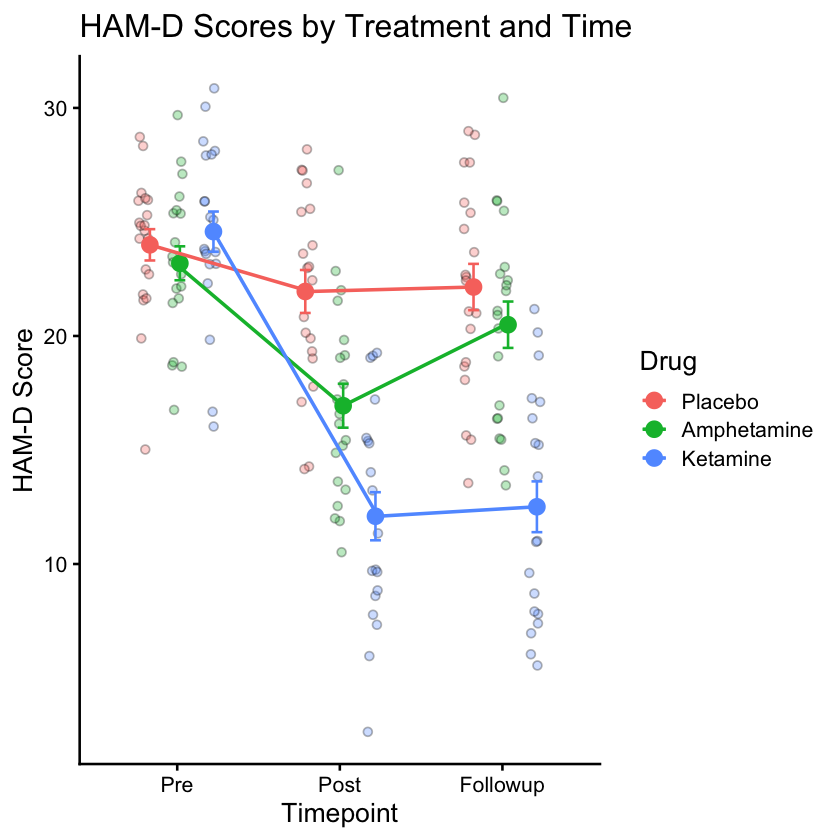

In [3]:
# visualize the effects
df_mixed_anova <- df %>%
    group_by(Drug, Time) %>%
    get_summary_stats(HAMD, type = "mean_sd")
# print(df_mixed_anova)

# plotting the effects
dodge <- position_jitterdodge(jitter.width = 0.2, dodge.width = 0.6)
p_depression_over_time <- ggplot(df, aes(x = Time, y = HAMD, fill = Drug, color=Drug)) +
  geom_jitter(shape= 21, color="black", size = 2, alpha = 0.3, position = dodge) +
  stat_summary(fun.data = "mean_se", geom = "errorbar", width = 0.2, position = dodge) +
  stat_summary(fun = "mean", geom = "point", size = 4, position = dodge) +
  stat_summary(aes(group = Drug),fun = "mean", geom = "line", size = 1, position = dodge) +
  theme_classic(base_size = 16) +
  ggtitle("HAM-D Scores by Treatment and Time") +
  xlab("Timepoint") +
  ylab("HAM-D Score")
plot(p_depression_over_time)

In [4]:
# Running the mixed mode
m_mixed_anova <- aov_ez(
    id = "Subject",
    dv = "HAMD",
    data = df,
    between = "Drug",
    within = "Time"
    )
summary(m_mixed_anova)

# running the EMmeans function
means_mixed <- emmeans(m_mixed_anova, pairwise ~ Drug | Time, adjust = "tukey")
kable(means_mixed$emmeans,digits=3, caption = "EMMeans from mixed ANOVA")
kable(means_mixed$contrasts,digits=3, caption = "PostHoc Tests from mixed ANOVA")

Contrasts set to contr.sum for the following variables: Drug




Univariate Type III Repeated-Measures ANOVA Assuming Sphericity

            Sum Sq num Df Error SS den Df  F value    Pr(>F)    
(Intercept)  70326      1  2633.03     57 1522.428 < 2.2e-16 ***
Drug          1210      2  2633.03     57   13.100 2.084e-05 ***
Time          1611      2   418.71    114  219.263 < 2.2e-16 ***
Drug:Time      843      4   418.71    114   57.403 < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Mauchly Tests for Sphericity

          Test statistic    p-value
Time             0.59011 3.8568e-07
Drug:Time        0.59011 3.8568e-07


Greenhouse-Geisser and Huynh-Feldt Corrections
 for Departure from Sphericity

           GG eps Pr(>F[GG])    
Time      0.70928  < 2.2e-16 ***
Drug:Time 0.70928  < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

             HF eps  Pr(>F[HF])
Time      0.7221494 1.82331e-29
Drug:Time 0.7221494 9.42384e-20



Table: EMMeans from mixed ANOVA

|Drug        |Time     | emmean|    SE| df| lower.CL| upper.CL|
|:-----------|:--------|------:|-----:|--:|--------:|--------:|
|Placebo     |Pre      | 23.997| 0.775| 57|   22.446|   25.549|
|Amphetamine |Pre      | 23.187| 0.775| 57|   21.636|   24.738|
|Ketamine    |Pre      | 24.576| 0.775| 57|   23.024|   26.127|
|Placebo     |Post     | 21.951| 0.988| 57|   19.974|   23.929|
|Amphetamine |Post     | 16.941| 0.988| 57|   14.963|   18.919|
|Ketamine    |Post     | 12.094| 0.988| 57|   10.116|   14.072|
|Placebo     |Followup | 22.147| 1.049| 57|   20.045|   24.248|
|Amphetamine |Followup | 20.493| 1.049| 57|   18.392|   22.594|
|Ketamine    |Followup | 12.509| 1.049| 57|   10.408|   14.611|



Table: PostHoc Tests from mixed ANOVA

|contrast               |Time     | estimate|    SE| df| t.ratio| p.value|
|:----------------------|:--------|--------:|-----:|--:|-------:|-------:|
|Placebo - Amphetamine  |Pre      |    0.810| 1.096| 57|   0.739|   0.741|
|Placebo - Ketamine     |Pre      |   -0.578| 1.096| 57|  -0.528|   0.858|
|Amphetamine - Ketamine |Pre      |   -1.389| 1.096| 57|  -1.267|   0.419|
|Placebo - Amphetamine  |Post     |    5.010| 1.397| 57|   3.587|   0.002|
|Placebo - Ketamine     |Post     |    9.857| 1.397| 57|   7.057|   0.000|
|Amphetamine - Ketamine |Post     |    4.847| 1.397| 57|   3.470|   0.003|
|Placebo - Amphetamine  |Followup |    1.654| 1.484| 57|   1.114|   0.509|
|Placebo - Ketamine     |Followup |    9.637| 1.484| 57|   6.494|   0.000|
|Amphetamine - Ketamine |Followup |    7.984| 1.484| 57|   5.380|   0.000|

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Drug and Time.
ℹ Output is grouped by Drug.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Drug, Time))` for per-operation grouping (`?dplyr::dplyr_by`) instead.


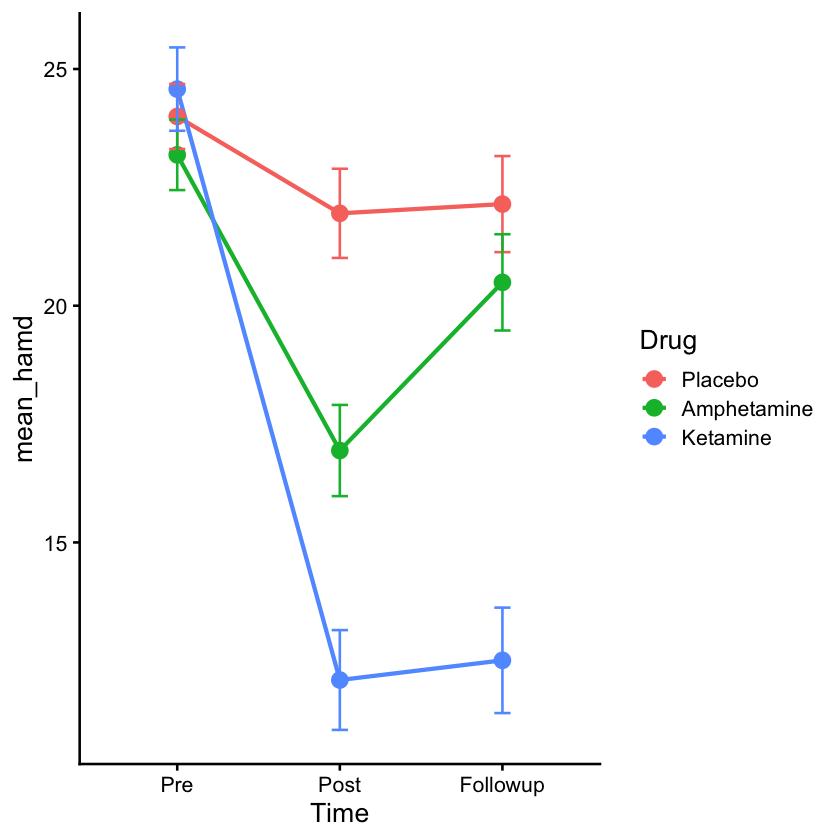

In [5]:
# Visualizing the effects
df_mixed_anova_summary <- df %>%
  group_by(Drug, Time) %>%
  summarise(mean_hamd = mean(HAMD),
            se_hamd = sd(HAMD) / sqrt(n()))

# Plotting the effects
p_mixed_anova <- ggplot(df_mixed_anova_summary, aes(x = Time, y = mean_hamd, color = Drug, group = Drug)) +
  geom_line(size = 1.2) +
  geom_point(size = 4) +
  geom_errorbar(aes(ymin = mean_hamd - se_hamd, ymax = mean_hamd + se_hamd), width = 0.1) +
  theme_classic(base_size=16)
p_mixed_anova

In [6]:
# Running the mixed model
m_mixed_anova <- aov_ez(id = "Subject", dv = "HAMD", between = "Drug", within = "Time", data = df)
summary(m_mixed_anova)

# running the estimated marginal means
means_mixed <- emmeans(m_mixed_anova, pairwise ~ Drug | Time, adjust = "tukey")
kable(means_mixed$emmeans, digits = 3, caption = "EMmeans from Mixed 3x3 ANOVA")
kable(means_mixed$contrasts, digits = 3, caption = "Post-Hoc Tests from Mixed 3x3 ANOVA")

Contrasts set to contr.sum for the following variables: Drug




Univariate Type III Repeated-Measures ANOVA Assuming Sphericity

            Sum Sq num Df Error SS den Df  F value    Pr(>F)    
(Intercept)  70326      1  2633.03     57 1522.428 < 2.2e-16 ***
Drug          1210      2  2633.03     57   13.100 2.084e-05 ***
Time          1611      2   418.71    114  219.263 < 2.2e-16 ***
Drug:Time      843      4   418.71    114   57.403 < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Mauchly Tests for Sphericity

          Test statistic    p-value
Time             0.59011 3.8568e-07
Drug:Time        0.59011 3.8568e-07


Greenhouse-Geisser and Huynh-Feldt Corrections
 for Departure from Sphericity

           GG eps Pr(>F[GG])    
Time      0.70928  < 2.2e-16 ***
Drug:Time 0.70928  < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

             HF eps  Pr(>F[HF])
Time      0.7221494 1.82331e-29
Drug:Time 0.7221494 9.42384e-20



Table: EMmeans from Mixed 3x3 ANOVA

|Drug        |Time     | emmean|    SE| df| lower.CL| upper.CL|
|:-----------|:--------|------:|-----:|--:|--------:|--------:|
|Placebo     |Pre      | 23.997| 0.775| 57|   22.446|   25.549|
|Amphetamine |Pre      | 23.187| 0.775| 57|   21.636|   24.738|
|Ketamine    |Pre      | 24.576| 0.775| 57|   23.024|   26.127|
|Placebo     |Post     | 21.951| 0.988| 57|   19.974|   23.929|
|Amphetamine |Post     | 16.941| 0.988| 57|   14.963|   18.919|
|Ketamine    |Post     | 12.094| 0.988| 57|   10.116|   14.072|
|Placebo     |Followup | 22.147| 1.049| 57|   20.045|   24.248|
|Amphetamine |Followup | 20.493| 1.049| 57|   18.392|   22.594|
|Ketamine    |Followup | 12.509| 1.049| 57|   10.408|   14.611|



Table: Post-Hoc Tests from Mixed 3x3 ANOVA

|contrast               |Time     | estimate|    SE| df| t.ratio| p.value|
|:----------------------|:--------|--------:|-----:|--:|-------:|-------:|
|Placebo - Amphetamine  |Pre      |    0.810| 1.096| 57|   0.739|   0.741|
|Placebo - Ketamine     |Pre      |   -0.578| 1.096| 57|  -0.528|   0.858|
|Amphetamine - Ketamine |Pre      |   -1.389| 1.096| 57|  -1.267|   0.419|
|Placebo - Amphetamine  |Post     |    5.010| 1.397| 57|   3.587|   0.002|
|Placebo - Ketamine     |Post     |    9.857| 1.397| 57|   7.057|   0.000|
|Amphetamine - Ketamine |Post     |    4.847| 1.397| 57|   3.470|   0.003|
|Placebo - Amphetamine  |Followup |    1.654| 1.484| 57|   1.114|   0.509|
|Placebo - Ketamine     |Followup |    9.637| 1.484| 57|   6.494|   0.000|
|Amphetamine - Ketamine |Followup |    7.984| 1.484| 57|   5.380|   0.000|

### 1.2 Key scenarios when linear mixed models (LMMs) are superior to ANOVA.
* Missing data.
* Unbalanced designs.
* Autocorrelated data.
* Timeseries data.
* Longitudinal data.
* Complex nested data structures.
    * e.g. Students within classrooms, patients within diagnostic categories, animals within a litter, etc.
* Continuous time.
* Strong violations of sphericity assumptions in rmANOVA.

### 1.3 Potential solution: Linear mixed models (LMMs)
* AKA mixed models, multilevel models, hierarchical models.
* LMMs don't rely on perfect, balanced matrices.
    * They look at all available data points.
    * If a subject has a Pre and Post score but no Followup, the LMM still uses their Pre and Post data to estimate the overall trajectories!
* Model works by maximizing the likelihood of the model given all the data we have.

### 1.4 How they work
* To understand how Linear Mixed Models handle this data, we need to split our variables into two distinct categories: __Fixed Effects__ and __Random Effects__.
    * Fixed Effects (`Drug` and `Time`): These are the experimental variables we actually care about testing and generalizing to the broader population. We want to know the universal, average effect of Ketamine versus Placebo over time.
    * Random Effects (`Subject`): This accounts for the idiosyncratic "noise" in our specific sample.
* The `R` Syntax: $HAMD$ ~ $Drug * Time + (1 | Subject)$
    * `Drug` * `Time` represents our __Fixed Effects__.
    * `(1 | Subject)` tells the model to add a __Random Intercept__ for each person.
* In plain English: "Calculate the overall, average effects of the Drug over Time, but allow every single subject to start at their own unique baseline level of depression."

In [9]:
# fit our linear mixed effects model
m_lmm <- lmer(HAMD ~ Drug * Time + (1 | Subject),df)

# print the omnibus table
# anova(m_lmm)
kable(as.data.frame(anova(m_lmm)), digits=3, caption = "Omnibus Model Table from LMM")



Table: Omnibus Model Table from LMM

|          |   Sum Sq| Mean Sq| NumDF| DenDF| F value| Pr(>F)|
|:---------|--------:|-------:|-----:|-----:|-------:|------:|
|Drug      |   96.228|  48.114|     2|    57|  13.100|      0|
|Time      | 1610.668| 805.334|     2|   114| 219.263|      0|
|Drug:Time |  843.347| 210.837|     4|   114|  57.403|      0|

In [10]:
# full coefficients table
summary(m_lmm)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: HAMD ~ Drug * Time + (1 | Subject)
   Data: df

REML criterion at convergence: 879

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.84472 -0.57870  0.03284  0.55485  2.41740 

Random effects:
 Groups   Name        Variance Std.Dev.
 Subject  (Intercept) 14.174   3.765   
 Residual              3.673   1.916   
Number of obs: 180, groups:  Subject, 60

Fixed effects:
                             Estimate Std. Error       df t value Pr(>|t|)    
(Intercept)                   23.9973     0.9446  75.6140  25.404  < 2e-16 ***
DrugAmphetamine               -0.8102     1.3359  75.6140  -0.607  0.54599    
DrugKetamine                   0.5785     1.3359  75.6140   0.433  0.66622    
TimePost                      -2.0460     0.6060 114.0000  -3.376  0.00101 ** 
TimeFollowup                  -1.8506     0.6060 114.0000  -3.054  0.00282 ** 
DrugAmphetamine:TimePost      -4.1999     

### 1.5 Visualizing the LMM interaction estimated marginal means

In [11]:
# getting estimates off the LMM object
predictions <- ggpredict(m_lmm, terms = c("Time","Drug"))
print(predictions)

# Predicted values of HAMD

Drug: Placebo

Time     | Predicted |       95% CI
-----------------------------------
Pre      |     24.00 | 22.13, 25.86
Post     |     21.95 | 20.09, 23.82
Followup |     22.15 | 20.28, 24.01

Drug: Amphetamine

Time     | Predicted |       95% CI
-----------------------------------
Pre      |     23.19 | 21.32, 25.05
Post     |     16.94 | 15.08, 18.81
Followup |     20.49 | 18.63, 22.36

Drug: Ketamine

Time     | Predicted |       95% CI
-----------------------------------
Pre      |     24.58 | 22.71, 26.44
Post     |     12.09 | 10.23, 13.96
Followup |     12.51 | 10.64, 14.37

Adjusted for:
* Subject = 0 (population-level)


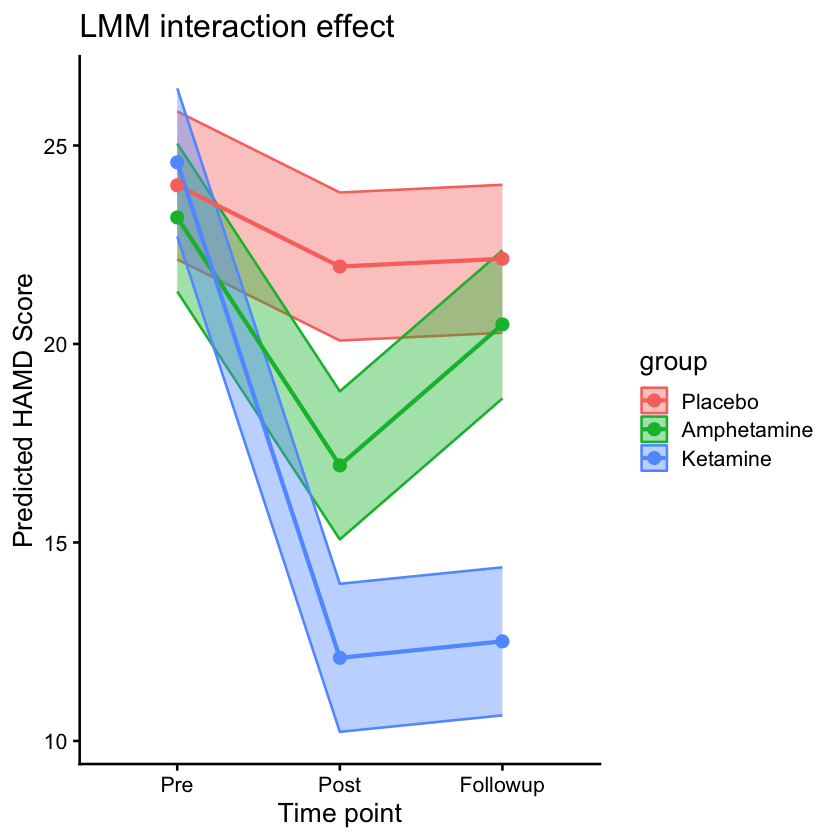

In [19]:
p_lmm_interaction <- ggplot(predictions, aes(x = x, y = predicted, color = group, fill = group, group = group)) +
    geom_ribbon(aes(ymin = conf.low, ymax = conf.high), alpha = 0.4) +
    geom_line(linewidth=1.2) +
    geom_point(size=3) +
    xlab("Time point") +
    ylab("Predicted HAMD Score") +
    ggtitle("LMM interaction effect") +
    theme_classic(base_size = 16)
p_lmm_interaction

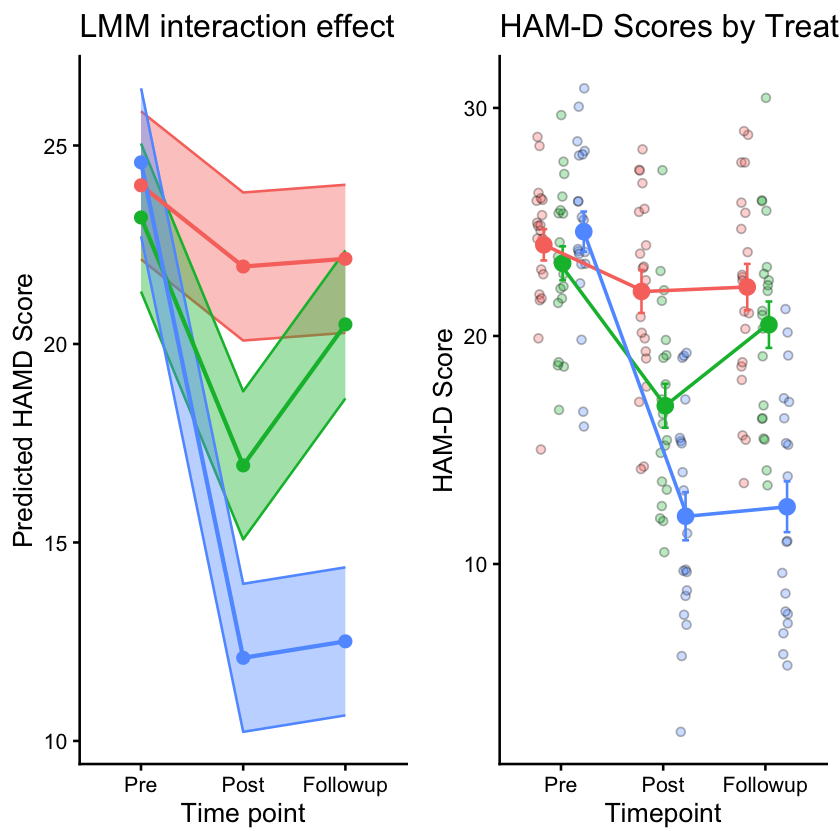

In [20]:
grid.arrange(p_lmm_interaction + theme(legend.position = "none"),
             p_depression_over_time + theme(legend.position = "none"),
             ncol = 2)

* Notice that the EMMs from the model map pretty directly onto the raw data plot
    * What happens if we covary for age and sex?


  M   F 
102  78 

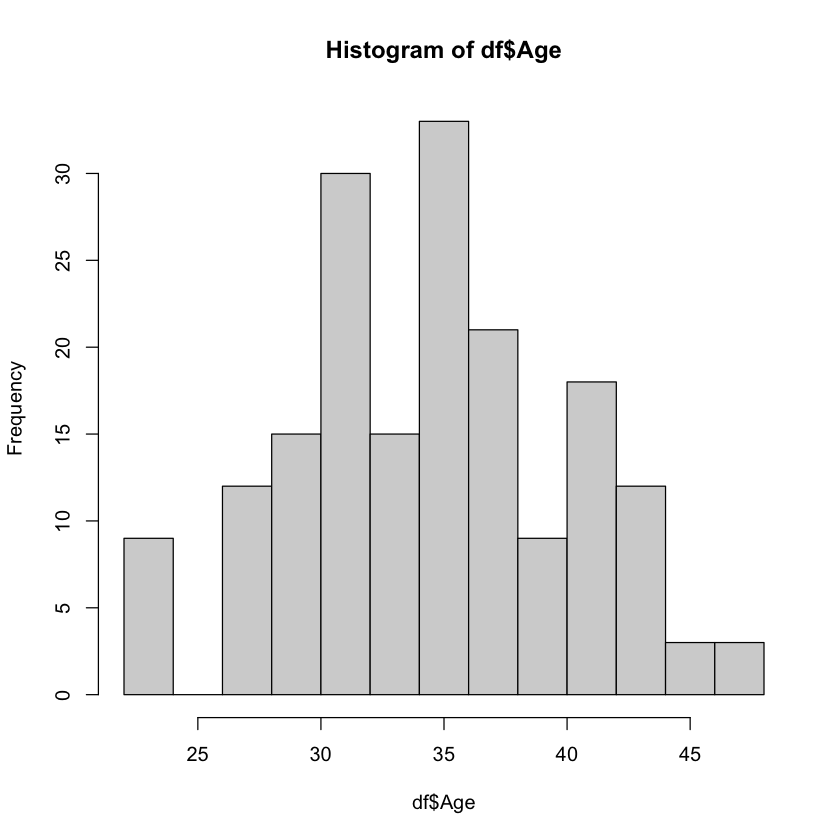

In [21]:
# adding age, between 20 and 60, to the data
df <- df %>%
  group_by(Subject) %>%
  mutate(
    Age = pmin(pmax(round(rnorm(1, mean = 35, sd = 5)), 20), 60),
    Sex = sample(c("M", "F"), 1)) %>%
  ungroup() %>%
  mutate(Sex = fct_relevel(as.factor(Sex), "M"))
hist(df$Age)
table(df$Sex, exclude = NULL)

In [22]:
# fit our linear mixed effects model
m_lmm_agesex <- lmer(HAMD ~ Drug * Time + Age + Sex + (1 | Subject), df)

# print the omnibus table and detailed coefficients table
kable(as.data.frame(anova(m_lmm_agesex)),digits=3, caption = "Omnibus Model Table from LMM, age sex covs")
summary(m_lmm_agesex)



Table: Omnibus Model Table from LMM, age sex covs

|          |   Sum Sq| Mean Sq| NumDF| DenDF| F value| Pr(>F)|
|:---------|--------:|-------:|-----:|-----:|-------:|------:|
|Drug      |   88.974|  44.487|     2|    55|  12.112|  0.000|
|Time      | 1610.668| 805.334|     2|   114| 219.263|  0.000|
|Age       |    3.574|   3.574|     1|    55|   0.973|  0.328|
|Sex       |    0.318|   0.318|     1|    55|   0.087|  0.770|
|Drug:Time |  843.347| 210.837|     4|   114|  57.403|  0.000|

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: HAMD ~ Drug * Time + Age + Sex + (1 | Subject)
   Data: df

REML criterion at convergence: 878.9

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.83307 -0.57474  0.02814  0.57113  2.43847 

Random effects:
 Groups   Name        Variance Std.Dev.
 Subject  (Intercept) 14.412   3.796   
 Residual              3.673   1.916   
Number of obs: 180, groups:  Subject, 60

Fixed effects:
                              Estimate Std. Error        df t value Pr(>|t|)
(Intercept)                   20.44625    3.57167  56.06855   5.725 4.23e-07
DrugAmphetamine               -0.51340    1.37341  71.86199  -0.374  0.70964
DrugKetamine                   0.74986    1.35980  72.25919   0.551  0.58303
TimePost                      -2.04601    0.60605 114.00000  -3.376  0.00101
TimeFollowup                  -1.85060    0.60605 114.00000  -3.054  0.00282
Age                            0.09337  

In [23]:
# getting estimates off the LMM object
predictions_agesex <- ggpredict(m_lmm_agesex, terms = c("Time","Drug"))
print(predictions)
print(predictions_agesex)

# Predicted values of HAMD

Drug: Placebo

Time     | Predicted |       95% CI
-----------------------------------
Pre      |     24.00 | 22.13, 25.86
Post     |     21.95 | 20.09, 23.82
Followup |     22.15 | 20.28, 24.01

Drug: Amphetamine

Time     | Predicted |       95% CI
-----------------------------------
Pre      |     23.19 | 21.32, 25.05
Post     |     16.94 | 15.08, 18.81
Followup |     20.49 | 18.63, 22.36

Drug: Ketamine

Time     | Predicted |       95% CI
-----------------------------------
Pre      |     24.58 | 22.71, 26.44
Post     |     12.09 | 10.23, 13.96
Followup |     12.51 | 10.64, 14.37

Adjusted for:
* Subject = 0 (population-level)
# Predicted values of HAMD

Drug: Placebo

Time     | Predicted |       95% CI
-----------------------------------
Pre      |     23.71 | 21.61, 25.81
Post     |     21.66 | 19.56, 23.76
Followup |     21.86 | 19.76, 23.96

Drug: Amphetamine

Time     | Predicted |       95% CI
-----------------------------------
Pre      |     23

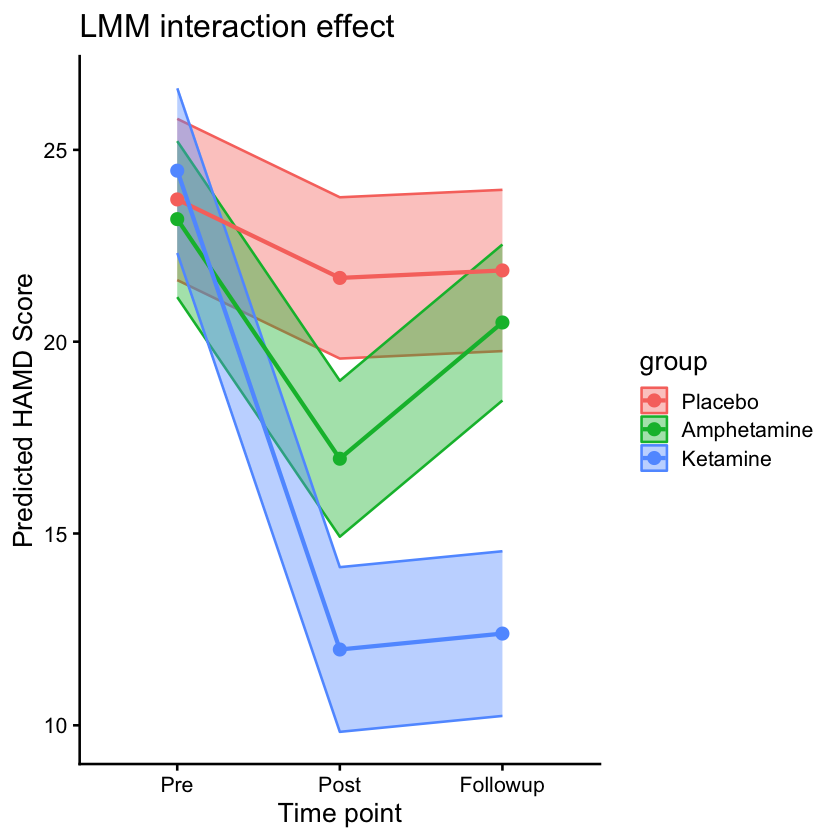

In [24]:
p_lmm_interaction_wagesex <- ggplot(predictions_agesex, aes(x = x, y = predicted, color = group, fill = group, group = group)) +
    geom_ribbon(aes(ymin = conf.low, ymax = conf.high), alpha = 0.4) +
    geom_line(linewidth=1.2) +
    geom_point(size=3) +
    xlab("Time point") +
    ylab("Predicted HAMD Score") +
    ggtitle("LMM interaction effect") +
    theme_classic(base_size = 16)
p_lmm_interaction_wagesex

### 1.6 The flexibility of LMMs
* LMMs can handle designs much more sophisticated than our simple `(1 | Subject)` random intercept.
* Two incredibly common extensions in clinical and neuroscience research are:
    * Nested Designs:
        * What if our sample included patients with two different underlying conditions (e.g., Major Depressive Disorder vs. Bipolar Depression)?
        * We can model this explicitly as a ___nested random intercept___
            * Changing our syntax to `(1 | Diagnosis/Subject)` tells the model: _"Subjects belong to specific Diagnostic groups; calculate an overarching baseline for MDD vs. BPD, and then calculate each individual Subject's baseline within their respective group."_
    * Random Slopes:
      * Our model assumes the drug worked at the exact same _rate_ for everyone (i.e., random intercepts, parallel slopes over Time).
      * In reality, Ketamine might drop depression scores incredibly fast for Subject 1, but very slowly for Subject 2, etc. 
      * We can add a ___Random Slope___ to explicitly model this variance
          * Changing our syntax to `(1 + Time | Subject)` tells the model: _"Give everyone their own starting baseline (intercept), AND allow everyone to have their own unique trajectory or rate of change (slope) over time."_
            
<img src="img/LMMs.png" width=600>
(<a href="https://peerj.com/articles/4794/">figure ref</a>)

# Section 2. General Linear Model (GLM) Assumptions.

<img src="img/decision_tree.png" width=300>

0. Outliers & influential observations
1. Independence
2. Normality
3. Equal variances

## 2.1 Before discussing each in turn, let's "break" our data a bit.

In [30]:
df_bad <- df %>%
  mutate(
    # Injecting conditional Skewness (a noticeable right-skew and heteroscedasticity for the assumptions check)
    HAMD = ifelse(Drug == "Ketamine" & Time != "Pre", 
                  HAMD + rexp(n(), rate = 0.4), 
                  HAMD),
    
    # Adding 15 points to just two random subjects.
    HAMD = ifelse(Subject %in% c(5, 12) & Time == "Post", 
                  HAMD + 15, 
                  HAMD)
  )

# visualizing the skewness in ketamine data
df_ketamine <- df_bad %>% filter(Drug=="Ketamine")
# hist(df_ketamine$HAMD)

# re-running the model with the bad data
m_lmm_baddata <- lmer(HAMD ~ Drug * Time + Age + Sex + (1 | Subject), df_bad)

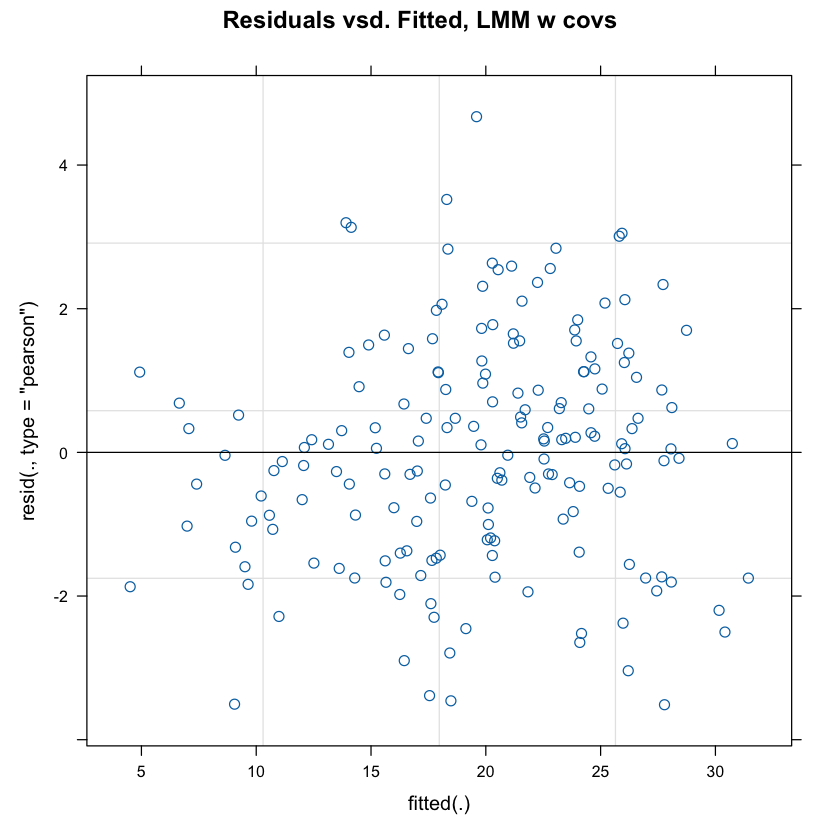

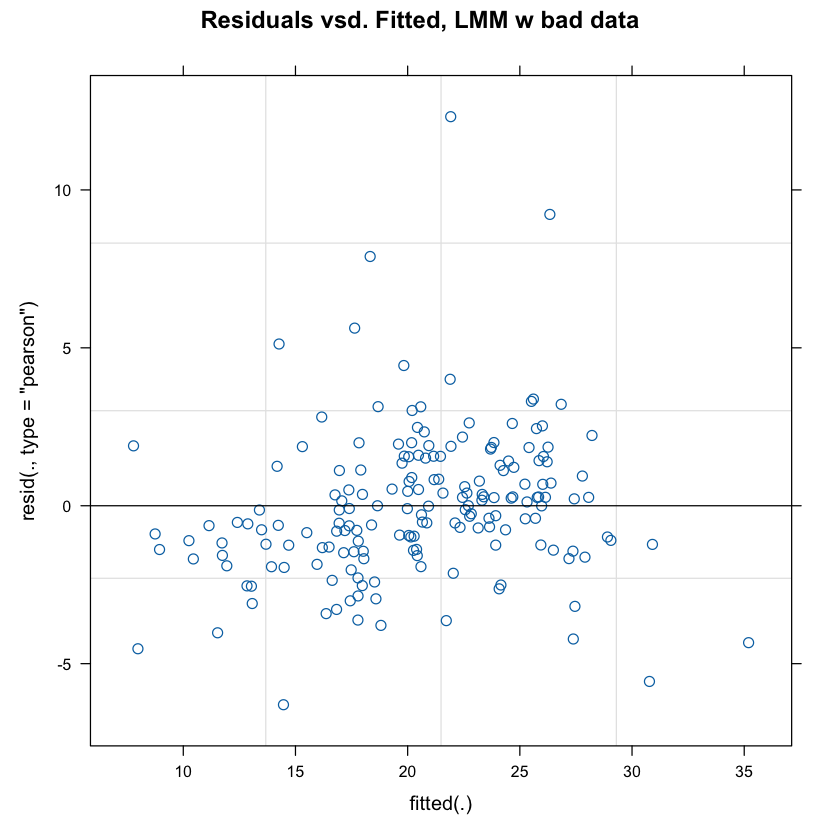

In [32]:
# Let's viosualize the damage
p_residuals_clean_data <- plot(m_lmm_agesex,main = "Residuals vsd. Fitted, LMM w covs")
p_residuals_clean_data
p_residuals_bad_data <- plot(m_lmm_baddata,main = "Residuals vsd. Fitted, LMM w bad data")
p_residuals_bad_data

### 2.2 Hunting for influential observations and outliers

* Outliers:

* Influential Observations:

### 2.3 GLM Assumptions: 


#### Independence
* ___Observations are independent of each other___
* Repeated-measures designs
    * e.g. within-subject observations across time often show "serial correlation" or "autocorrelation"
* Nested designs (e.g. workers on a team, team within a department, departments within an org.)
* For `lm`, use `durbinWatsonTest(model)`
* For `lmer`, check the residuals plot

#### Normality
* ___There is an assumption that the data are normally distributed___
* Most datasets contain at least one non-gaussian variable...
    * That doesn't _necessarily_ matter. The key is: Are the model error terms (i.e., residuals) normally distributed?
* For `lm`, use `shapiro.test(model)`
* For `lmer`, check the residuals plot

#### Equal variances 
* ___Across different types of GLM-family tests, there are common assumptions about equal variances___
* Homogeneity of variance: Differences, single predictor variable (e.g. t.test, one-way ANOVA)
* Sphericity: Differences, multilevel factor(s) (e.g. repeated-measures and mixed model ANOVA)
* Homoscedasticity: Continuous, do predictor variables have similar variance (e.g. multiple regression)
* For ...
    * `t.test`, use `var.test`
    * `anova`, use `bartlett.test`
    * `lm`, use `car::ncvTest`
* For `lmer`, check the residuals plot